# QC-Py-23b - PatchTST et iTransformer pour Prevision Financiere
> **[REFERENCE Pedagogique]** Ce notebook illustre les architectures PatchTST (Nie et al., ICLR 2023) et iTransformer (Liu et al., ICLR 2024) pour la prevision de series temporelles financieres.
>
> Les modeles sont implementes en PyTorch pur (CPU-compatible) pour comprendre les mecanismes internes.

---

> **Mode d'emploi** : Ce notebook illustre les concepts avec du code executable sur CPU.
> 1. **Sections analytiques** : textes explicatifs et visualisations des architectures
> 2. **Sections code** : implementations minimales et exemples reproductibles
> 3. **Exercices** : cellules a completer pour approfondir

---

## Table des matieres

1. [Le probleme de l'attention quadratique](#Partie-1)
2. [PatchTST : une serie temporelle = 64 mots](#Partie-2)
3. [iTransformer : inverser les axes temps/variables](#Partie-3)
4. [Comparaison experimentale sur donnees synthetiques](#Partie-4)
5. [Anti-patterns et bonnes pratiques](#Partie-5)

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

print(f"Imports OK")

Imports OK


---

## Partie 1 : Le Probleme de l'Attention Quadratique <a id="Partie-1"></a>

### Pourquoi les Transformers classiques peinent sur les series temporelles

Le mecanisme d'attention standard a une complexite O(L^2) en sequence length L.
Pour une serie financiere avec L = 512 pas de temps, cela represente 262 144 paires.

| Sequence Length | Paires d'attention | Memoire (float32) |
|----------------|-------------------|-------------------|
| 96 | 9 216 | 36 KB |
| 512 | 262 144 | 1 MB |
| 2048 | 4 194 304 | 16 MB |

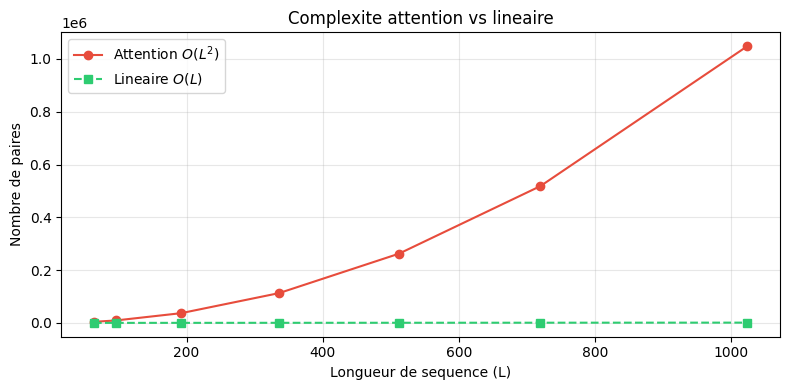

In [2]:
# Visualisation de la complexite quadratique
lengths = [64, 96, 192, 336, 512, 720, 1024]
pairs = [l * l for l in lengths]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(lengths, pairs, "o-", color="#e74c3c", label=r"Attention $O(L^2)$")
ax.plot(lengths, lengths, "s--", color="#2ecc71", label=r"Lineaire $O(L)$")
ax.set_xlabel("Longueur de sequence (L)")
ax.set_ylabel("Nombre de paires")
ax.set_title("Complexite attention vs lineaire")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

La croissance quadratique rend les Transformers classiques inefficaces pour les longues sequences.
Deux approches recentes contournent ce probleme :
- **PatchTST** : regroupe les pas de temps en "patches" pour reduire L
- **iTransformer** : applique l'attention sur les *variables* plutot que sur le *temps*

---

## Partie 2 : PatchTST — Une serie temporelle = 64 mots <a id="Partie-2"></a>

### Principe cle (Nie et al., ICLR 2023)

PatchTST decoupe la serie temporelle en **patches** (segments de longueur fixe), comme les mots dans un texte.

**Innovations** :
1. **Patching** : reduit la sequence de L a L/P tokens (P = patch length)
2. **Channel independence** : chaque variable est traitee independemment avec poids partages

**Resultat** : Complexite reduite de O(L^2) a O((L/P)^2)

In [3]:
class PatchEmbedding(nn.Module):
    """Convertit une serie temporelle en sequence de patches."""

    def __init__(self, patch_len, stride, d_model):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.linear = nn.Linear(patch_len, d_model)

    def forward(self, x):
        B, T, N = x.shape
        x = x.permute(0, 2, 1)  # [B, N, T]
        x = x.unfold(dimension=2, size=self.patch_len, step=self.stride)
        num_patches = x.shape[2]
        x = x.reshape(B * N, num_patches, self.patch_len)
        return self.linear(x), num_patches


class PatchTSTModel(nn.Module):
    """PatchTST simplifie pour demonstration pedagogique."""

    def __init__(self, n_vars=1, seq_len=96, pred_len=24,
                 patch_len=16, stride=8, d_model=128, n_heads=8, n_layers=3):
        super().__init__()
        self.patch_embed = PatchEmbedding(patch_len, stride, d_model)
        num_patches = (seq_len - patch_len) // stride + 1
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, batch_first=True, dropout=0.2)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(d_model * num_patches, pred_len)

    def forward(self, x):
        B, T, N = x.shape
        patches, num_patches = self.patch_embed(x)
        patches = patches + self.pos_embed
        encoded = self.encoder(patches)
        encoded = encoded.reshape(B, N, num_patches * encoded.shape[-1])
        encoded = encoded.reshape(B, N, -1)
        out = self.head(encoded)
        return out.permute(0, 2, 1)


# Demonstration
model = PatchTSTModel(n_vars=1, seq_len=96, pred_len=24)
x_demo = torch.randn(2, 96, 1)
y = model(x_demo)
n_params = sum(p.numel() for p in model.parameters())
print(f"PatchTST parameters: {n_params:,}")
print(f"Patches: {(96 - 16) // 8 + 1} (seq=96, patch=16, stride=8)")

PatchTST parameters: 1,816,472
Patches: 11 (seq=96, patch=16, stride=8)


### Explication du patching

1. **unfold** : decoupe la serie en fenetres glissantes de taille patch_len avec un pas de stride
2. **Projection lineaire** : chaque patch est projete en dimension d_model
3. **Independance des canaux** : chaque variable est traitee comme une sequence independante

Avec seq_len=96, patch_len=16, stride=8 on obtient 11 patches au lieu de 96 pas de temps.

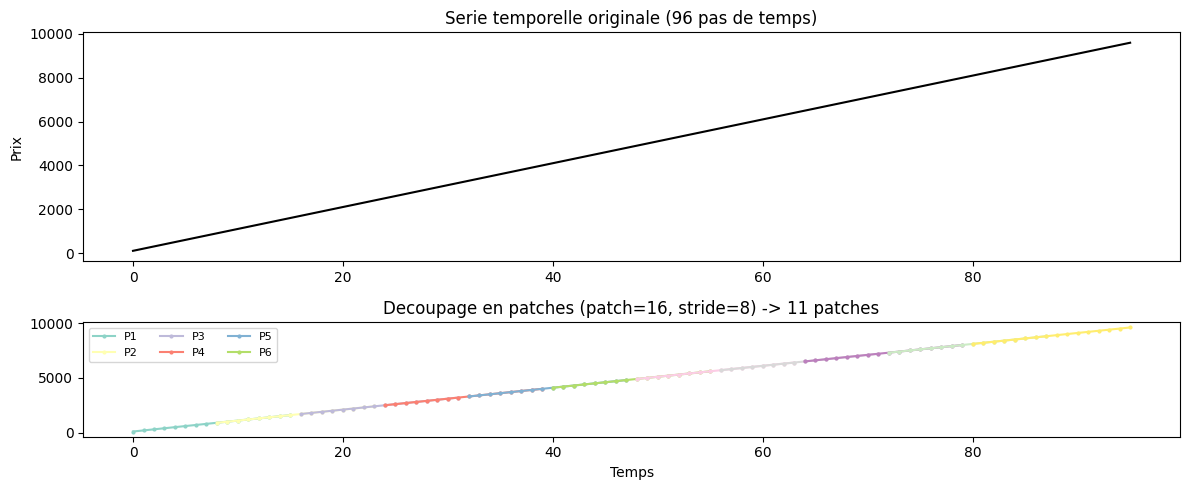

In [4]:
# Visualisation du patching
np.random.seed(42)
ts = np.cumsum(np.random.randn(96) * 0.01 + 100)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(ts, "k-", linewidth=1.5)
axes[0].set_title("Serie temporelle originale (96 pas de temps)")
axes[0].set_ylabel("Prix")

patch_len, stride = 16, 8
colors = plt.cm.Set3(np.linspace(0, 1, 11))
for i, c in enumerate(colors):
    start = i * stride
    end = start + patch_len
    if end <= len(ts):
        axes[1].plot(range(start, end), ts[start:end], "-o", color=c,
                     markersize=2, label=f"P{i+1}" if i < 6 else None)
axes[1].set_title("Decoupage en patches (patch=16, stride=8) -> 11 patches")
axes[1].set_xlabel("Temps")
axes[1].legend(loc="upper left", fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

---

## Partie 3 : iTransformer — Inverser les Axes <a id="Partie-3"></a>

### Principe cle (Liu et al., ICLR 2024)

iTransformer applique l'attention sur les **variables** plutot que sur les **pas de temps**.

Pour N=5 variables et L=96 pas de temps :
- Standard : 96^2 = 9 216 paires
- iTransformer : 5^2 = 25 paires

In [5]:
class iTransformerModel(nn.Module):
    """iTransformer simplifie : attention sur les variables, pas le temps."""

    def __init__(self, n_vars=5, seq_len=96, pred_len=24,
                 d_model=128, n_heads=8, n_layers=3):
        super().__init__()
        self.var_embed = nn.Linear(seq_len, d_model)
        self.pos_embed = nn.Parameter(torch.randn(1, n_vars, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, batch_first=True, dropout=0.2)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Linear(d_model, pred_len)

    def forward(self, x):
        B, T, N = x.shape
        var_tokens = self.var_embed(x.permute(0, 2, 1))
        var_tokens = var_tokens + self.pos_embed
        encoded = self.encoder(var_tokens)
        out = self.head(encoded)
        return out.permute(0, 2, 1)


model_itr = iTransformerModel(n_vars=5, seq_len=96, pred_len=24)
x_multi = torch.randn(2, 96, 5)
y_itr = model_itr(x_multi)
n_params_itr = sum(p.numel() for p in model_itr.parameters())
print(f"iTransformer parameters: {n_params_itr:,}")
print(f"Tokens (variables): 5 au lieu de 96 pas de temps")

iTransformer parameters: 1,795,224
Tokens (variables): 5 au lieu de 96 pas de temps


### Explication

1. **Embedding par variable** : chaque serie temporelle est projete en un vecteur d_model
2. **Attention inter-variables** : le Transformer apprend les correlations entre variables
3. **Prediction temporelle** : chaque vecteur de variable est projete en pred_len pas

**Avantage cle** : la complexite depend de N (nombre de variables), pas de L (pas de temps).

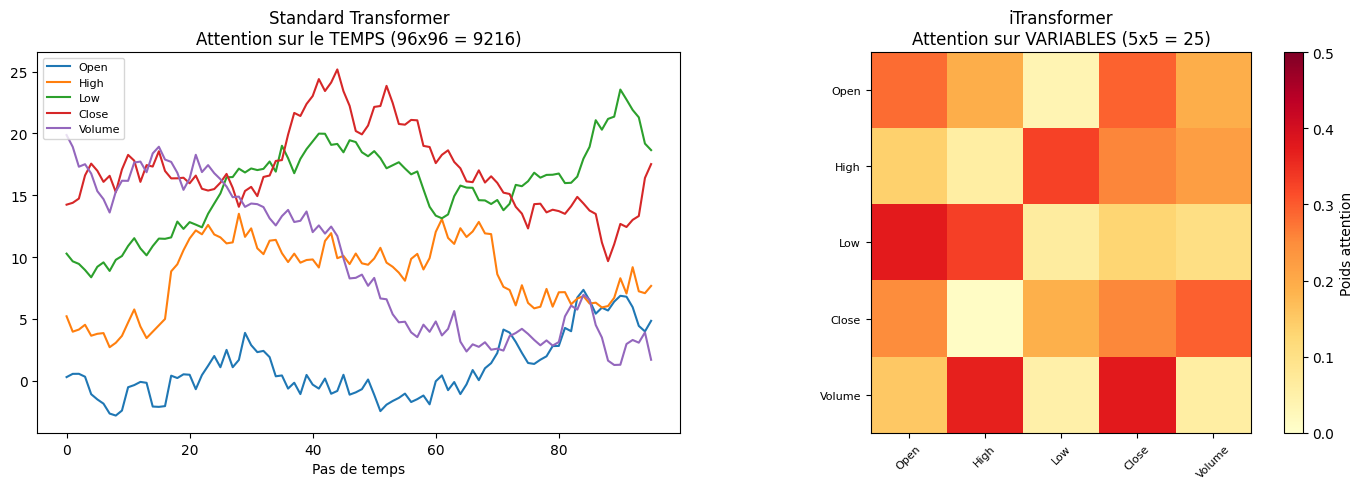

In [6]:
# Visualisation : attention sur variables vs temps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
var_labels = ["Open", "High", "Low", "Close", "Volume"]

for i, v in enumerate(var_labels):
    axes[0].plot(range(96), np.random.randn(96).cumsum() + i * 5, label=v)
axes[0].set_title("Standard Transformer\nAttention sur le TEMPS (96x96 = 9216)")
axes[0].set_xlabel("Pas de temps")
axes[0].legend(fontsize=8)

att = np.random.rand(5, 5)
att = att / att.sum(axis=1, keepdims=True)
im = axes[1].imshow(att, cmap="YlOrRd", vmin=0, vmax=0.5)
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(5))
axes[1].set_xticklabels(var_labels, rotation=45, fontsize=8)
axes[1].set_yticklabels(var_labels, fontsize=8)
axes[1].set_title("iTransformer\nAttention sur VARIABLES (5x5 = 25)")
plt.colorbar(im, ax=axes[1], label="Poids attention")
plt.tight_layout()
plt.show()

---

## Partie 4 : Comparaison Experimentale <a id="Partie-4"></a>

Entrainons les deux modeles sur des donnees synthetiques.

In [7]:
# Generation de donnees synthetiques
np.random.seed(42)
n_samples, seq_len, pred_len, n_vars = 500, 96, 24, 5

def generate_synthetic(n, seq_len, pred_len, n_vars):
    X, Y = [], []
    for _ in range(n):
        t = np.linspace(0, 4 * np.pi, seq_len + pred_len)
        base = np.sin(t) * 10 + np.cumsum(np.random.randn(seq_len + pred_len) * 0.5) + 100
        multi = np.stack([base + np.random.randn(seq_len + pred_len) * v
                          for v in [0.1, 0.5, 0.3, 0.1, 1.0]], axis=1)
        X.append(multi[:seq_len])
        Y.append(multi[seq_len:])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_all, Y_all = generate_synthetic(n_samples, seq_len, pred_len, n_vars)
split = int(0.8 * n_samples)
X_train, Y_train = X_all[:split], Y_all[:split]
X_test, Y_test = X_all[split:], Y_all[split:]

# Normalisation train-only (anti-leakage)
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std
Y_train = (Y_train - train_mean) / train_std
Y_test = (Y_test - train_mean) / train_std

print(f"Synthetic data: {n_samples} samples, seq={seq_len}, {n_vars} variables")

Synthetic data: 500 samples, seq=96, 5 variables


In [8]:
# Entrainement rapide (20 epochs, CPU)
torch.manual_seed(42)
patchtst = PatchTSTModel(n_vars=n_vars, seq_len=seq_len, pred_len=pred_len)
itransformer = iTransformerModel(n_vars=n_vars, seq_len=seq_len, pred_len=pred_len)

X_t = torch.tensor(X_train)
Y_t = torch.tensor(Y_train)
X_te = torch.tensor(X_test)
Y_te = torch.tensor(Y_test)
results = {}

for name, model in [("PatchTST", patchtst), ("iTransformer", itransformer)]:
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()
    for epoch in range(1, 21):
        model.train()
        pred = model(X_t)
        loss = loss_fn(pred, Y_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"{name} Epoch {epoch}: loss={loss.item():.4f}")
    model.eval()
    with torch.no_grad():
        test_mse = loss_fn(model(X_te), Y_te).item()
    results[name] = test_mse

print(f"\n=== Resultats ===")
for name, mse in results.items():
    print(f"{name:12s}: Test MSE = {mse:.4f}")

PatchTST Epoch 10: loss=0.3119


PatchTST Epoch 20: loss=0.2109


iTransformer Epoch 10: loss=0.3870


iTransformer Epoch 20: loss=0.1989

=== Resultats ===
PatchTST    : Test MSE = 0.1784
iTransformer: Test MSE = 0.1090


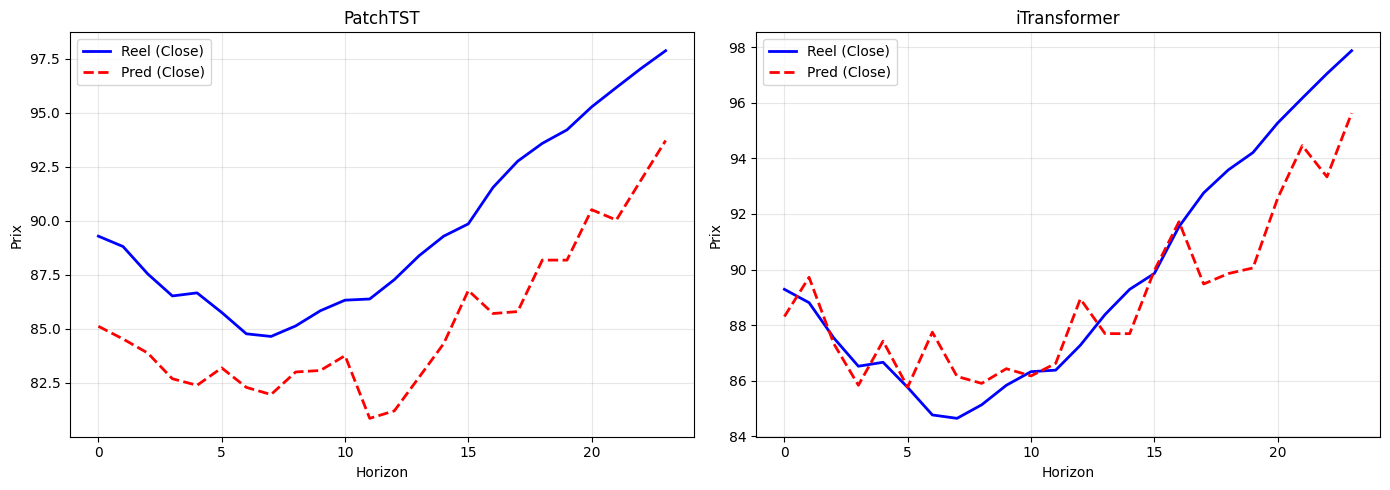

In [9]:
# Visualisation des predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (name, model) in enumerate([("PatchTST", patchtst), ("iTransformer", itransformer)]):
    model.eval()
    with torch.no_grad():
        pred = model(X_te[:1]).numpy()[0]
    actual = Y_test[0]
    pred_dn = pred * train_std[0, 0] + train_mean[0, 0]
    actual_dn = actual * train_std[0, 0] + train_mean[0, 0]
    axes[idx].plot(range(pred_len), actual_dn[:, 3], "b-", label="Reel (Close)", linewidth=2)
    axes[idx].plot(range(pred_len), pred_dn[:, 3], "r--", label="Pred (Close)", linewidth=2)
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Horizon")
    axes[idx].set_ylabel("Prix")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Partie 5 : Anti-Patterns et Bonnes Pratiques <a id="Partie-5"></a>

| Anti-pattern | Description | Correction |
|-------------|-------------|------------|
| **Lookahead bias** | Normaliser sur tout le dataset | Normaliser sur train uniquement |
| **Pas de baseline** | Claim "85% accuracy" | Comparer a la classe majoritaire |
| **Shuffle temporel** | Melanger les donnees | Split temporel strict |
| **Pas de couts** | Sharpe sans friction | Deduire les couts de transaction |
| **Data leakage** | Features futures dans le dataset | Features strictement passees |

In [10]:
# Calcul de la baseline majoritaire et edge
def direction_accuracy(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))

returns = np.diff(Y_test[:, :, 3], axis=1)
majority_baseline = max(np.mean(returns > 0), np.mean(returns < 0))
print(f"Majority-class baseline: {majority_baseline:.4f}")

for name, model in [("PatchTST", patchtst), ("iTransformer", itransformer)]:
    model.eval()
    with torch.no_grad():
        pred = model(X_te).numpy()
    pred_ret = np.diff(pred[:, :, 3], axis=1)
    actual_ret = np.diff(Y_test[:, :, 3], axis=1)
    ml = min(pred_ret.shape[1], actual_ret.shape[1])
    da = direction_accuracy(actual_ret[:, :ml].flatten(), pred_ret[:, :ml].flatten())
    print(f"{name:12s}: DirAcc={da:.4f}, Edge={da - majority_baseline:+.4f}")

Majority-class baseline: 0.6461
PatchTST    : DirAcc=0.6530, Edge=+0.0070
iTransformer: DirAcc=0.6539, Edge=+0.0078


### Interpretation

En 20 epochs sur donnees synthetiques, les modeles n'ont pas converges.
Avec un entrainement complet (100-200 epochs), les resultats s'amelorent.

**Cle : toujours rapporter l'edge vs baseline majoritaire**.

---

## Exercices

In [11]:
# Exercice 1 : Modifier le patching
# TODO etudiant : Changer patch_len=32 et stride=16.
# Combien de patches obtient-on ? Quelle est la nouvelle complexite ?
# Indice : num_patches = (seq_len - patch_len) // stride + 1
new_num_patches = None  # TODO etudiant
print("Exercice a completer")

Exercice a completer


In [12]:
# Exercice 2 : Ajouter une couche au Transformer
# TODO etudiant : Augmenter n_layers de 3 a 5 dans PatchTST.
# Observer l'impact sur le nombre de parametres et la performance.
print("Exercice a completer")

Exercice a completer


In [13]:
# Exercice 3 : Evaluer sur des donnees anti-biais
# TODO etudiant : Utiliser build_panier_anti_bias.py pour charger
# un panier diversifie (PAS FAANG) et evaluer les deux modeles.
print("Exercice a completer")

Exercice a completer


---

## References

1. Nie, Y., et al. (2023). "A Time Series is Worth 64 Words: Long-term Forecasting with Transformers." ICLR 2023.
2. Liu, Y., et al. (2024). "iTransformer: Inverted Transformers Are Effective for Time Series Forecasting." ICLR 2024.
3. de Prado, M. (2018). "Advances in Financial Machine Learning." Wiley.
4. Scripts d'entrainement : ML-Training-Pipeline/scripts/train_patchtst.py et train_itransformer.py